[TOC]

# 我使用了什么库？

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from torch import dtype


**Q:** 所以这些库的作用是？

# 然后，我要干什么？

打算可视化梯度下降

**Q:** 梯度下降是什么？有什么作用？为什么要可视化它？

> 想可视化梯度下降就需要一个对象，和对应的数据，所以需要

# 模型: 线性回归

以最简单的线性回归模型为例

**Q:** 线性回归模型的公式和每个参数的意义

> 想可视化梯度下降就需要一个对象，和对应的数据，所以需要

# 数据生成

要生成的数据分为两部分:
- 特征(题目)
- 标签(参考答案)

生成方式：特征随机在0和1之间生成100个点，标签在指定的参数下经计算得来(确定值)

**Q:** 伪随机数是什么？种子在其中的作用

In [2]:
# numpy教程: 随机数

# 多次运行比较结果
np.random.seed(33)
# 1个数
print(np.random.randn(1),np.random.randint(1,5))

# 多维数组
print(np.random.randn(2,1))
print(np.random.randn(2,3))


[-0.31885351] 3
[[-1.60298056]
 [ 0.63443794]]
[[ 1.40935364 -0.96912075 -0.09047386]
 [ 1.06918594 -0.44105642 -0.68655947]]


In [3]:
# 程序1-1: 生成随机的特征和标签
# seed: 42

N=100
true_b=1
true_w=2

np.random.seed(42)
x = np.random.rand(N,1)
ep = .1*np.random.randn(N,1)
y=true_b+true_w*x +ep

print(x.shape,y.shape)

(100, 1) (100, 1)


## 获得数据后的第一步:拆分

**Q**: 要把数据拆成几个部分？

**Q**: 打算数据的意义是什么？ 有什么例外？

In [4]:
# 程序1-2: 拆分数据(以索引分割)

#打乱索引

idx = np.arange(N)
print("打乱前:",idx[:10])
np.random.shuffle(idx)
print("打乱后:",idx[:10])

# 使用前80个索引进行训练
train_idx = idx[:int(N*0.8)]
# 使用剩余的索引进行验证
val_idx = idx[int(N*0.8):]

# 生成训练和验证集
x_train,y_train = x[train_idx],y[train_idx]
x_val,y_val = x[val_idx],y[val_idx]


打乱前: [0 1 2 3 4 5 6 7 8 9]
打乱后: [76 83 80 98  2 77 71 84 89 50]


In [5]:
# numpy教程: 索引访问

# 生成0-19
d = np.arange(20)
np.random.shuffle(d)
print(d)

# 偶数索引
i = np.arange(2,20,2)

print(i)

# 对应内容
print(d[i])
print(d[1:10:3])
print(d[slice(1,10,2)])


[ 7  2 10  3 11  5  1 12 15  0 14  8  6 13 17 19  4 16 18  9]
[ 2  4  6  8 10 12 14 16 18]
[10 11  1 15 14  6 17  4 18]
[ 2 11 12]
[ 2  3  5 12  0]


> 或许可以使用`train_test_split`替代

# 然后，我要干什么？

现在已经有了数据和模型，该进行梯度下降的计算和可视化了。

**Q**: 梯度下降有哪些步骤？


# Step0: 随机初始化

In [6]:
# 程序1-3: 随机初始化参数b和w

np.random.seed(42)

b = np.random.randn(1)
w = np.random.randn(1)

print(b,w)


[0.49671415] [-0.1382643]


# Step1: 计算模型的预测（前向传递）

In [7]:
# 程序1-4: 前向传递

yhat = b + w * x_train

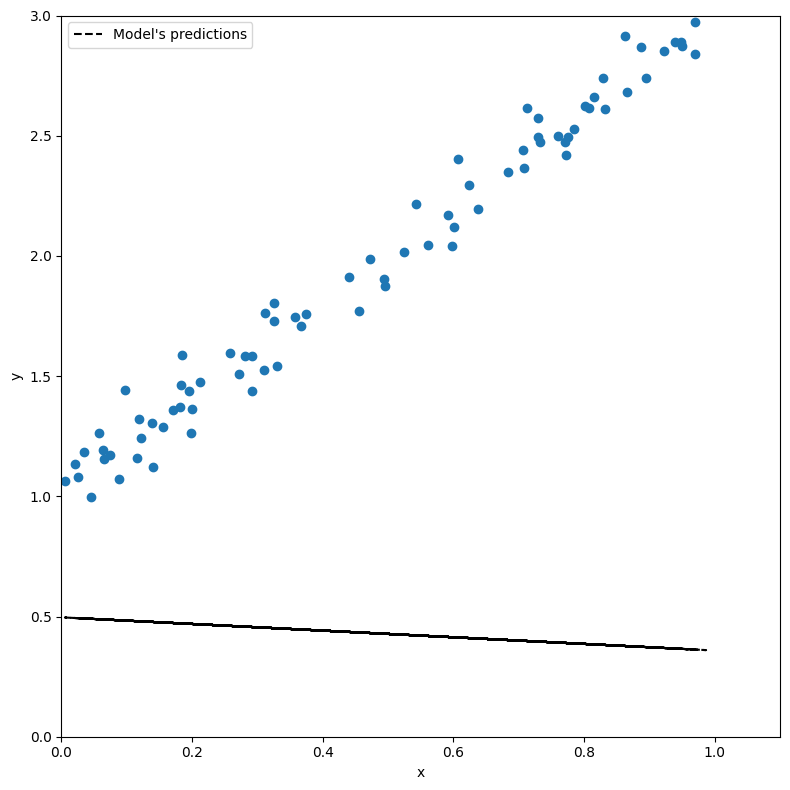

In [8]:
# Matplotlib教程: 绘图
import matplotlib.pyplot as plt
# plot()：用于绘制线图和散点图
# scatter()：用于绘制散点图
# bar()：用于绘制垂直条形图和水平条形图
# hist()：用于绘制直方图
# pie()：用于绘制饼图
# imshow()：用于绘制图像
# subplots()：用于创建子图

# 创建子图,结构是(1,1),figsize代表图分辨率
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 设置轴名称
ax.set_xlabel('x')
ax.set_ylabel('y')

# 设置显示区间
ax.set_xlim([0, 1.1])
ax.set_ylim([0, 3])

# 散点图:训练数据
ax.scatter(x_train, y_train)
# 线图: 实际预测数据
ax.plot(x_train, yhat, label='Model\'s predictions', c='k', linestyle='--')

# 显示图例
ax.legend(loc=0)

# 确保元素不重叠
fig.tight_layout()




# Step2: 计算损失

**Q**: 什么是误差？什么是损失？

**Q**: 有几种梯度下降的方式？区别在哪？

**Q**: 机器学习要解决的问题分为哪两类？

**Q**: 回归问题的损失误差函数是什么?

In [9]:
# 程序 1-5: 计算损失(批量梯度下降版)

# 误差
error = yhat - y_train

# 损失(MSE)
loss = (error**2).mean()

print("loss",loss)

loss 2.7421577700550976


## 损失面

现在要干什么?
- 打算展示所有w和b组合对损失函数的影响

第一步是列出所有可能的b,w,损失组合


In [10]:
# 程序 1-6: 列出所有可能的b,w,损失组合

b_range = np.linspace(true_b-3,true_b+3,101)
w_range = np.linspace(true_w-3,true_w+3,101)

bs,ws = np.meshgrid(b_range, w_range)

print("bs.shape,ws.shape",bs.shape,ws.shape)


all_preds = np.apply_along_axis(
    func1d=lambda x:bs+ws *x,
    axis=1, #80行1列，求函数时是拿一个数出来算的
    arr=x_train
)

#数据是80条,每条数据对应101X101种b和w的组合
print("x_train.shape,all_preds.shape",x_train.shape,all_preds.shape)

# 转换标签的形状
print("y_train.shape",y_train.shape)
all_lables= y_train.reshape(-1,1,1)
print("all_lables.shape",all_lables.shape)

# 计算误差
all_errors = (all_preds - all_lables)
print("all_errors.shape",all_errors.shape)


# 计算损失
all_losses = (all_errors ** 2).mean(axis=0)
print("all_losses.shape",all_losses.shape)




bs.shape,ws.shape (101, 101) (101, 101)
x_train.shape,all_preds.shape (80, 1) (80, 101, 101)
y_train.shape (80, 1)
all_lables.shape (80, 1, 1)
all_errors.shape (80, 101, 101)
all_losses.shape (101, 101)


In [11]:
# numpy教程: apply_along_axis
# 参考: https://zhuanlan.zhihu.com/p/31275071

rr = np.array([[1,2,3],[10,20,30]])
print("rr:",rr)
print("行 rr[0]:",rr[0])
print("列 rr[...,0]:",rr[...,0])
print("rr.shape",rr.shape)

print("axis=0::",np.sum(rr,axis=0)) # 顺列求和，压缩行
print("axis=1::",np.sum(rr,axis=1)) # 顺行求和，压缩列

print("axis=1",np.apply_along_axis(
    func1d=lambda x:x+1,
    axis=1,
    arr=rr))



rr: [[ 1  2  3]
 [10 20 30]]
行 rr[0]: [1 2 3]
列 rr[...,0]: [ 1 10]
rr.shape (2, 3)
axis=0:: [11 22 33]
axis=1:: [ 6 60]
axis=1 [[ 2  3  4]
 [11 21 31]]


In [12]:
# numpy教程: linspace

# -2到2闭区间 5等分
print(np.linspace(-2,2,5))
# 类比arrange
print(np.arange(-2,2.1,1))


[-2. -1.  0.  1.  2.]
[-2. -1.  0.  1.  2.]


In [13]:
# numpy教程: meshgrid


# 定义x和y的值
x = np.array([1, 2, 3])
y = np.array([4, 5, 6, 7])

# 使用meshgrid生成网格点矩阵
X, Y = np.meshgrid(x, y)

# 打印生成的网格点矩阵
print("X网格点矩阵:")
print(X)
print("Y网格点矩阵:")
print(Y)


X网格点矩阵:
[[1 2 3]
 [1 2 3]
 [1 2 3]
 [1 2 3]]
Y网格点矩阵:
[[4 4 4]
 [5 5 5]
 [6 6 6]
 [7 7 7]]


第二步是可视化损失面的步骤

(101, 101) (101, 101) (101, 101)


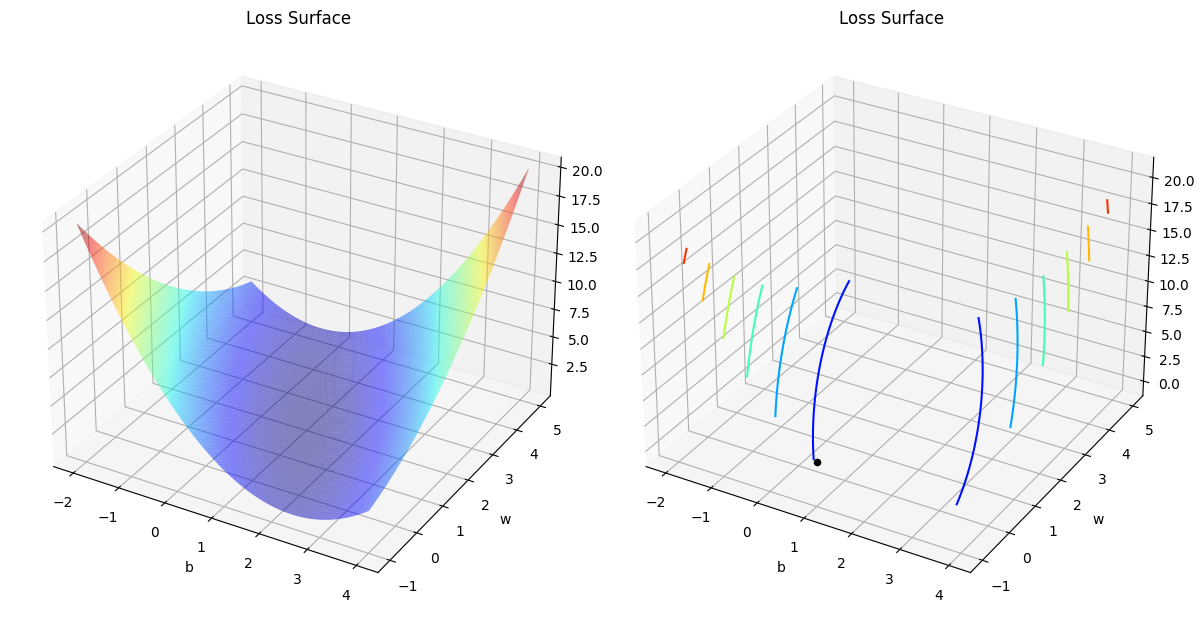

In [14]:
# 程序1-7: 展示损失面

# 绘制曲面
fig, ax = plt.subplots(1, 2, figsize=(12, 12),subplot_kw=dict(projection='3d'))

ax[0].set_xlabel('b')
ax[0].set_ylabel('w')
ax[0].set_title('Loss Surface')

print(ws.shape,bs.shape,all_losses.shape)

ax[0].plot_surface(bs, ws, all_losses, rstride=1, cstride=1, alpha=.5, cmap=plt.cm.jet, linewidth=0, antialiased=True)


# contour() 绘制等高线（轮廓线），contourf() 绘制填充等高线
CS = ax[1].contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)

ax[1].set_xlabel('b')
ax[1].set_ylabel('w')
ax[1].set_title('Loss Surface')
ax[1].clabel(CS, inline=1, fontsize=10)
ax[1].scatter(b, w, c='k')
ax[1].annotate('Random Start', xy=(-.2, 0.05), c='k')
ax[1].annotate('Minimum', xy=(.5, 2.2), c='k')

fig.tight_layout()



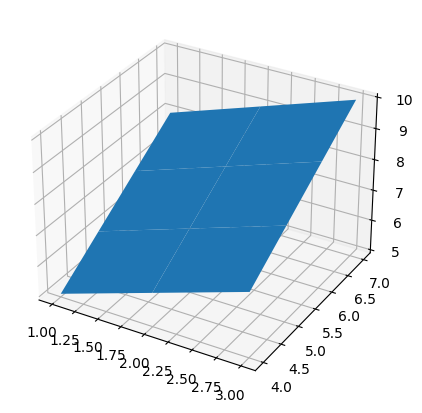

In [15]:
# matplot教程: 曲面图

# 定义x和y的值
x = np.array([1, 2, 3])
y = np.array([4, 5, 6, 7])

# 使用meshgrid生成网格点矩阵
X, Y = np.meshgrid(x, y)

# 使用网格点矩阵计算一个函数的值
Z = X + Y

fig, ax = plt.subplots(1, 1, figsize=(5, 5),subplot_kw=dict(projection='3d'))
ax.plot_surface(X, Y, Z)

## 横截面

现在要干什么？

**Q**: 解释图中虚直线的意义

**Q**: 解释两个曲线代表的意义

**Q**: 解释两个曲线不同代表着什么,对学习有什么影响




(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='Loss'>],
       dtype=object))

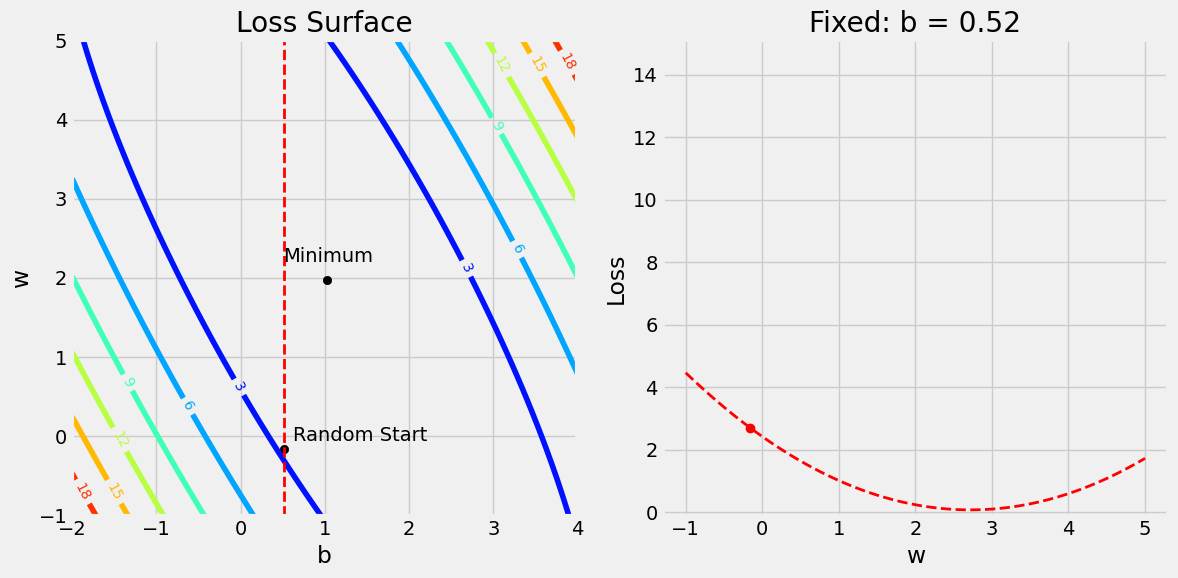

In [16]:
from plots.chapter0 import *

# 横截面可视化(b)
figure5(x_train, y_train, b, w, bs, ws, all_losses)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b', ylabel='Loss'>],
       dtype=object))

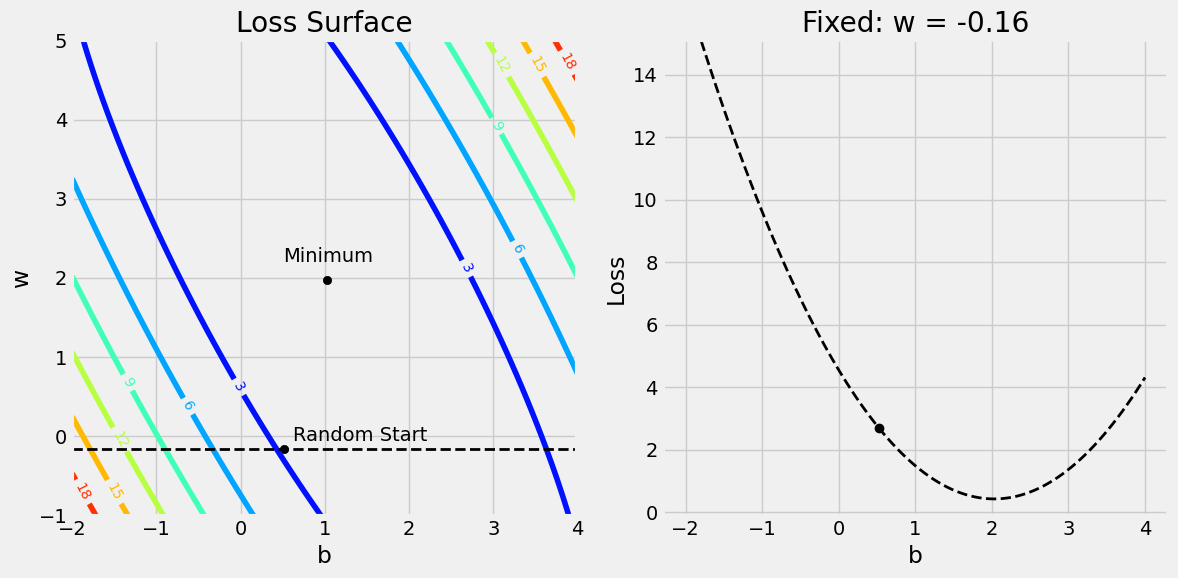

In [17]:
# 横截面可视化（w)
figure6(x_train, y_train, b, w, bs, ws, all_losses)

# Step3: 计算梯度

**Q**: 偏导数是什么？

**Q**: 梯度对于损失代表着什么？


In [18]:
# 程序1-8: 计算参数b和w的梯度

b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()

print(b_grad,w_grad)

-3.044811379650508 -1.8337537171510832


## 可视化梯度

**Q**: 梯度和曲线的形状有什么关系？

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

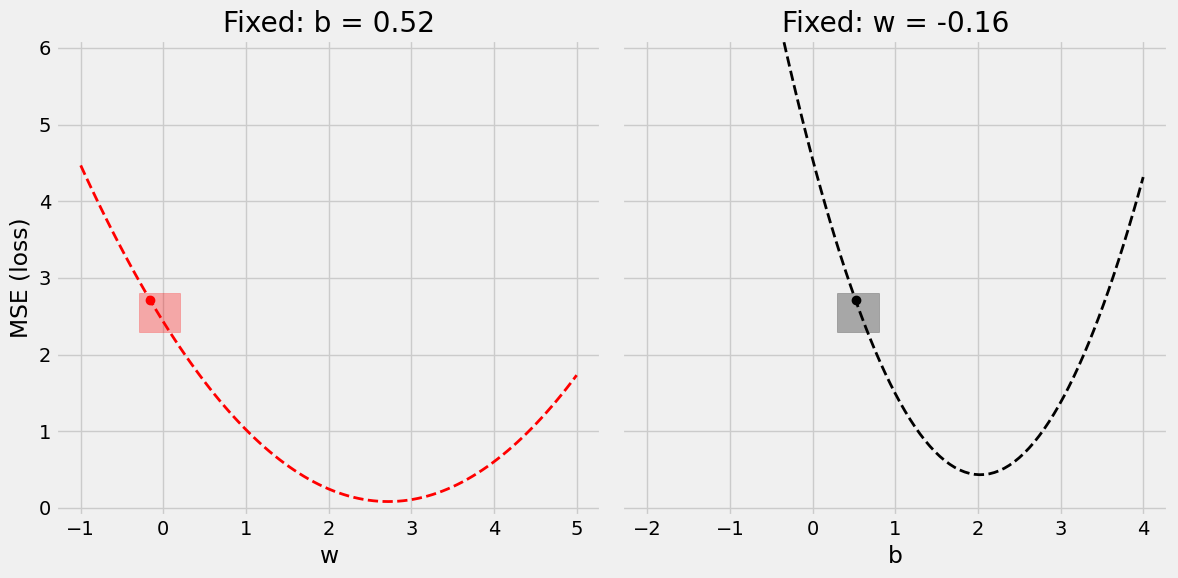

In [19]:
figure7(b, w, bs, ws, all_losses)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

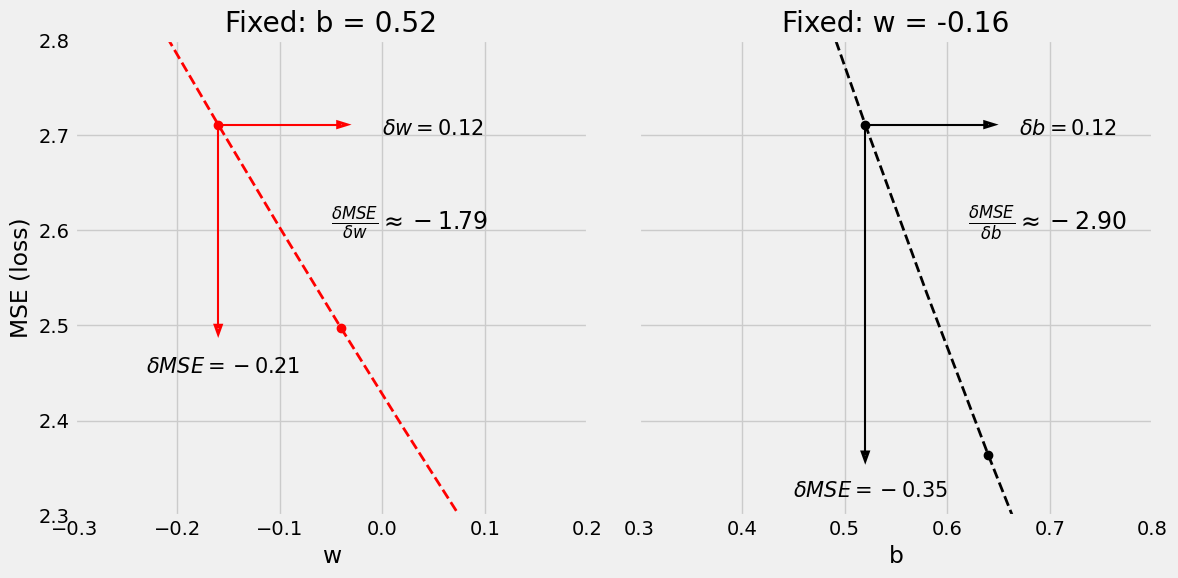

In [20]:
# 对比w和b的梯度变化
figure8(b, w, bs, ws, all_losses)

## 反向传播

**Q**: 链式规则是什么？

**Q**: 反向传播是什么？

# Step4: 更新参数

**Q**: 什么是超参数?

**Q**: 什么是学习率?

In [21]:
# 程序 1-9: 设置学习率并更新参数

lr = 0.1

print(b,w)

# 使用梯度和学习率更新参数

b = b - lr * b_grad
w = w - lr * w_grad

print(b,w)

[0.49671415] [-0.1382643]
[0.80119529] [0.04511107]


D:\projectCode\AI\PyTorchStepByStep\plots\chapter0.py:368: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

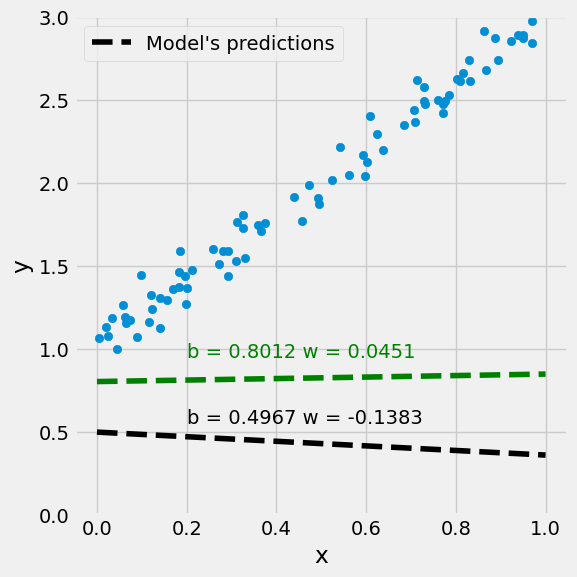

In [22]:
# 可视化结果
figure9(x_train, y_train, b, w)


## 学习率

**Q**: 结合所示图,学习率大小和学习效果有什么关系？

In [23]:
manual_grad_b = -2.90
manual_grad_w = -1.79

np.random.seed(42)
b_initial = np.random.randn(1)
w_initial = np.random.randn(1)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

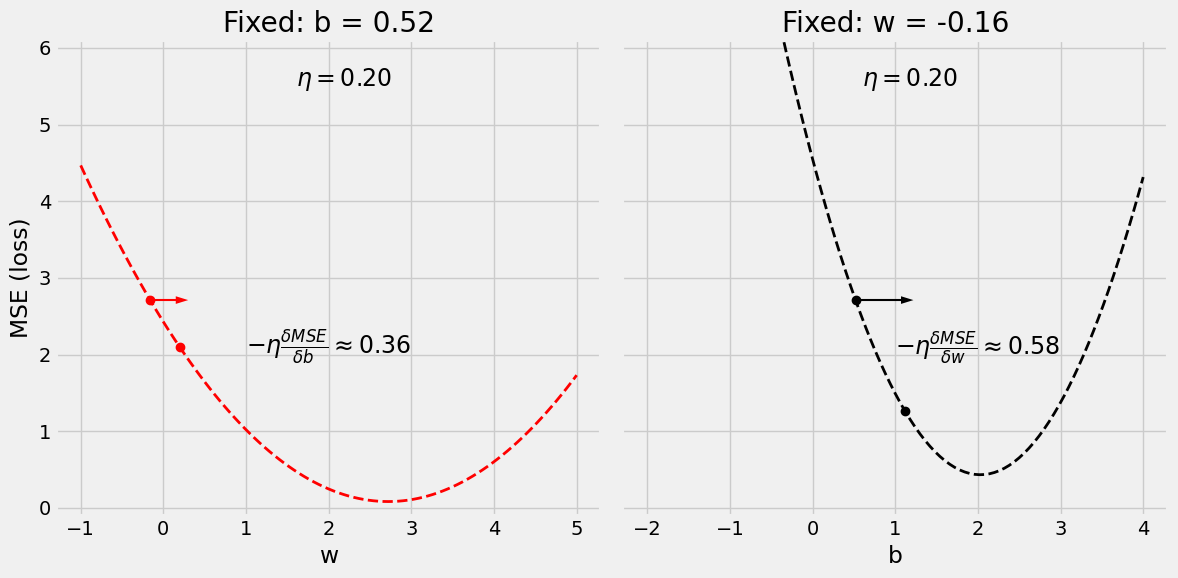

In [24]:
# Learning rate - greek letter "eta" that looks like an "n"
lr = .2

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

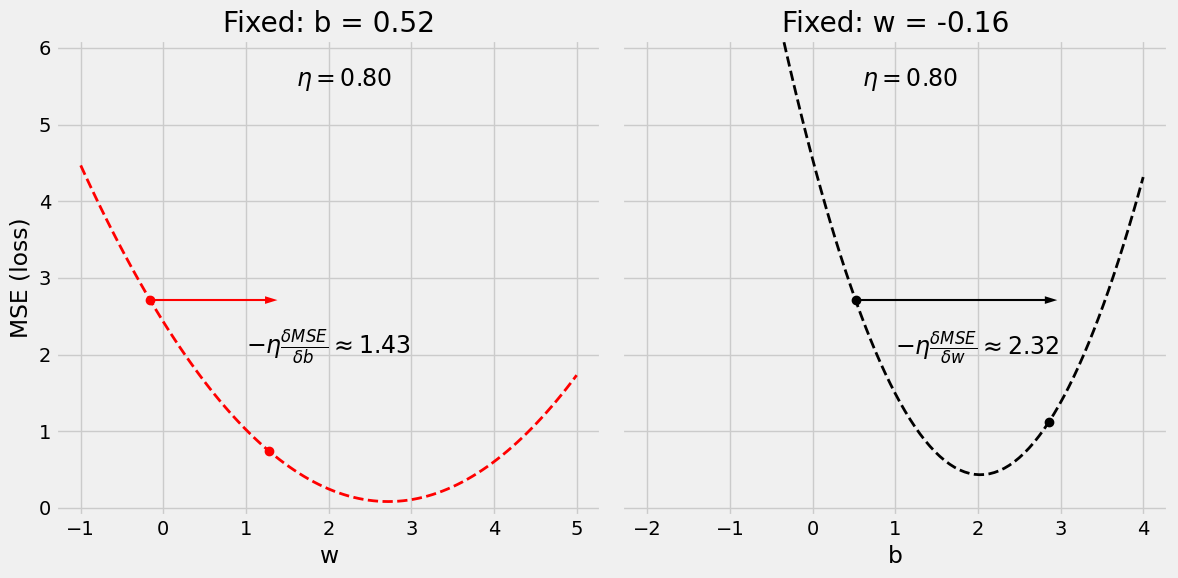

In [25]:
# Learning rate - greek letter "eta" that looks like an "n"
lr = .8

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

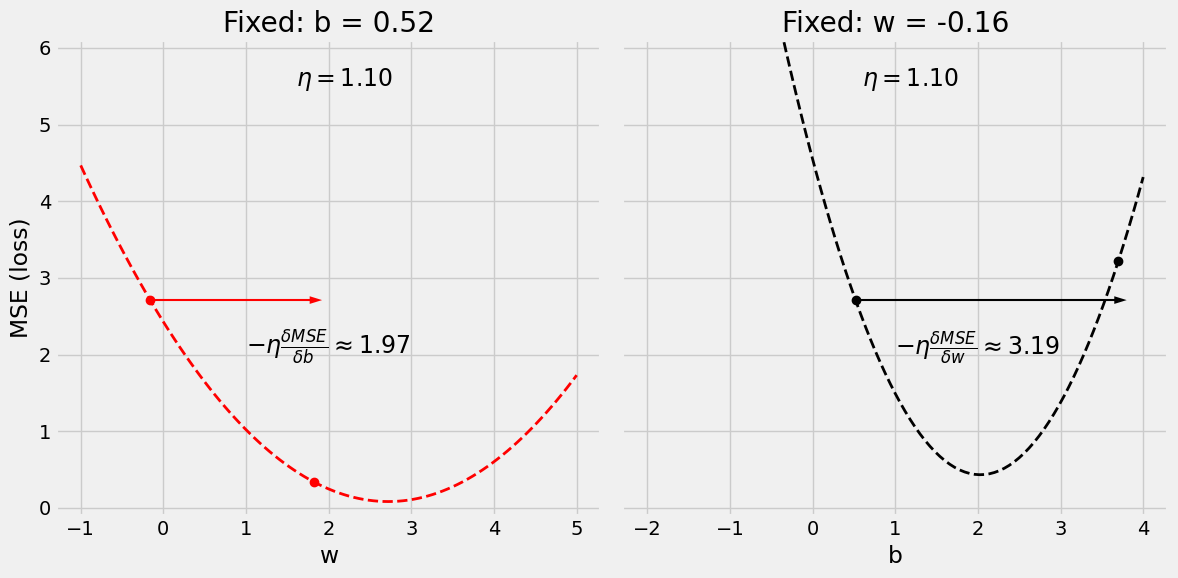

In [26]:
# Learning rate - greek letter "eta" that looks like an "n"
lr = 1.1

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)

# Step4.1: 标准化

## 特征对学习的影响

**Q**: 看图,解释分布较差的特征对学习的影响

In [27]:
true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)

# 更改特征x的范围
# 将w除以10
bad_w = true_w / 10
# 将x乘以10
bad_x = np.random.rand(N, 1) * 10

# 所以，对y的纯影响为0
#它仍然和以前一样
y = true_b + bad_w * bad_x + (.1 * np.random.randn(N, 1))

In [28]:
# 生成训练集和验证集
# 它使用与之前相同的train_idx和val_idx
# 但它适用于bad_x
bad_x_train, y_train = bad_x[train_idx], y[train_idx]
bad_x_val, y_val = bad_x[val_idx], y[val_idx]

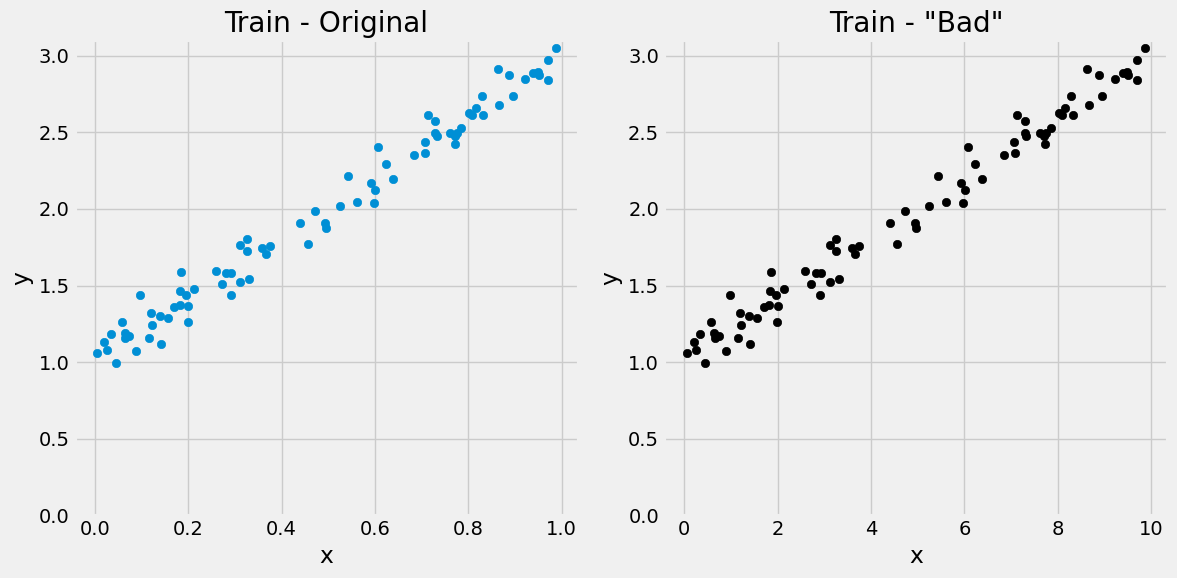

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].scatter(x_train, y_train)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_ylim([0, 3.1])
ax[0].set_title('Train - Original')
ax[1].scatter(bad_x_train, y_train, c='k')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_ylim([0, 3.1])
ax[1].set_title('Train - "Bad"')
fig.tight_layout()

In [30]:
# 范围改变了，因为我们以新的最小值为中心，使用了“坏”数据
bad_b_range = np.linspace(-2, 4, 101)
bad_w_range = np.linspace(-2.8, 3.2, 101)
bad_bs, bad_ws = np.meshgrid(bad_b_range, bad_w_range)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Surface - Before'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Loss Surface - After'}, xlabel='b', ylabel='w'>],
       dtype=object))

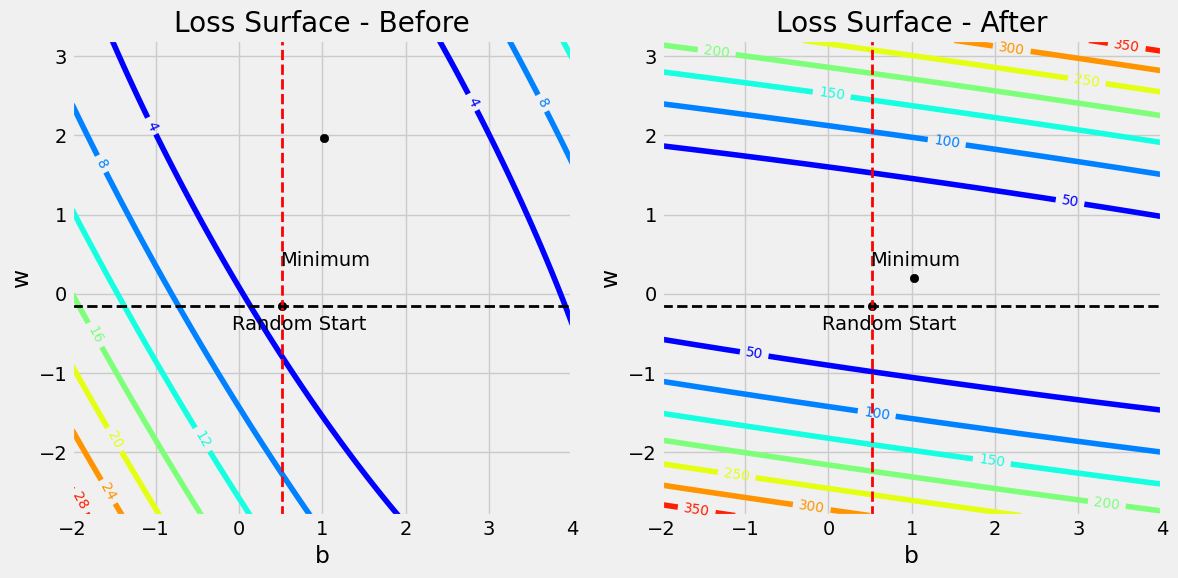

In [31]:
figure14(x_train, y_train, b_initial, w_initial, bad_bs, bad_ws, bad_x_train)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='Loss'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b', ylabel='Loss'>],
       dtype=object))

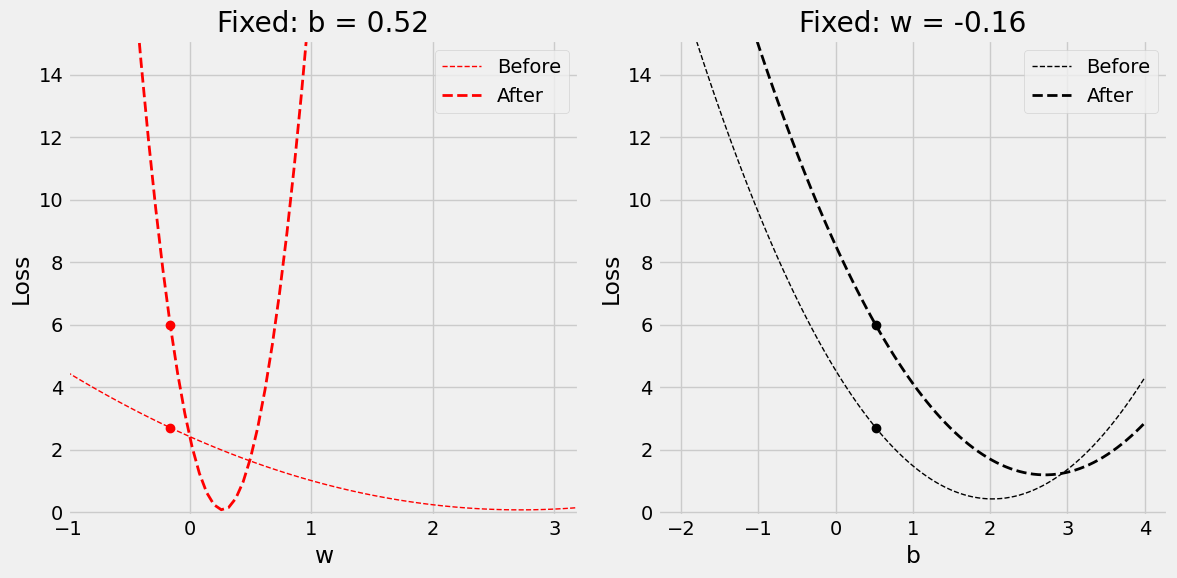

In [32]:
figure15(x_train, y_train, b_initial, w_initial, bad_bs, bad_ws, bad_x_train)

## 标准化-归一化-缩放

**Q**: 这是什么？为什么话题到了这个地方？

**Q**: 标准化后的均值和标准差有什么特点？

**Q**: 如何对数据集进行标准化？（均值，标准差，和缩放公式）有什么注意事项？

**Q**: 为什么标准化后的特征对学习有好处？

In [33]:
# 程序1-10: 标准化

scaler = StandardScaler(with_mean=True,with_std=True)
# 只用训练集拟合缩放
scaler.fit(x_train)

# 用拟合的缩放转换训练和验证集
scaled_x_train = scaler.transform(x_train)
scaled_x_val = scaler.transform(x_val)


(<Figure size 1500x600 with 3 Axes>,
 array([<Axes: title={'center': 'Loss Surface - Original'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Loss Surface - "Bad"'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Loss Surface - Scaled'}, xlabel='b', ylabel='w'>],
       dtype=object))

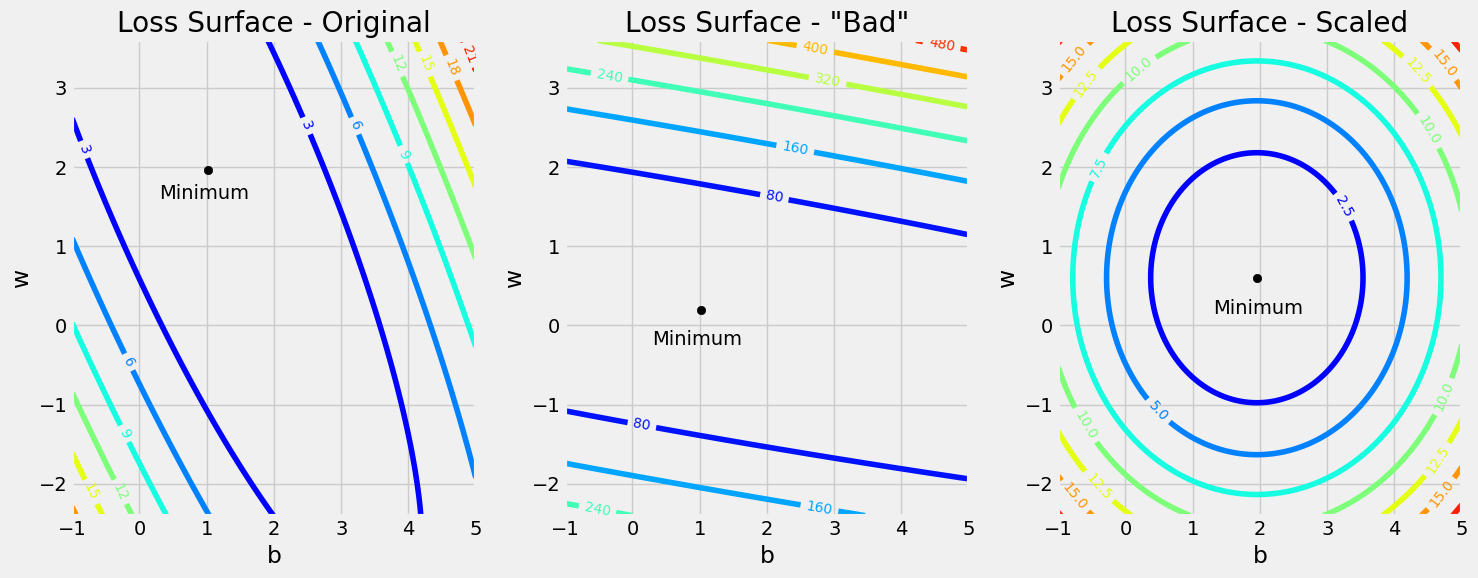

In [34]:
# 可视化损失面
# 范围再次发生变化，因为我们正以新的最小值为中心，使用“缩放”后的数据
scaled_b_range = np.linspace(-1, 5, 101)
scaled_w_range = np.linspace(-2.4, 3.6, 101)
scaled_bs, scaled_ws = np.meshgrid(scaled_b_range, scaled_w_range)

figure17(x_train, y_train, scaled_bs, scaled_ws, bad_x_train, scaled_x_train)

# Step 5: 循环往复

**Q**: Epoch周期是什么？

**Q**: 不同的梯度下降,每个周期更新多少次？

**Q**: 根据图片分析三种梯度下降的特点（稳定还是快速？）

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

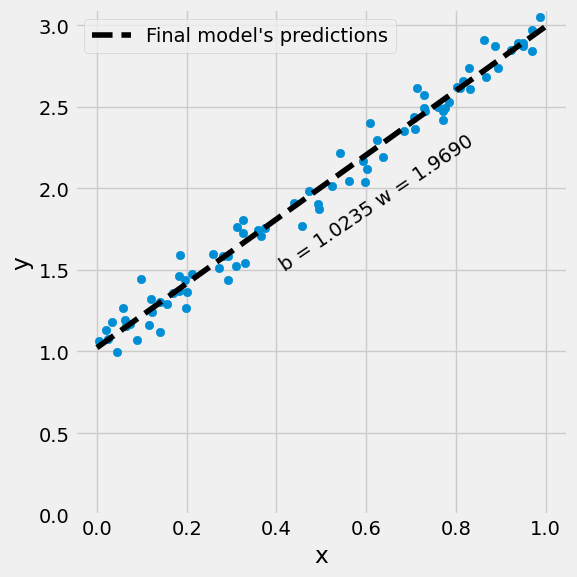

In [35]:
# 结果可视化
figure18(x_train, y_train)

![](../images/paths.png)